In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [2]:
# generate dataset
#define parameters
A = np.random.rand(10000) + 0.5
omega = 1.5 * np.random.rand(10000) + 0.5
phi = 2 * np.pi * np.random.rand(10000)
t = np.linspace(0, 4 * np.pi, 100)
clean_curve = np.zeros([10000, 100])
for i in range(100):
    x = lambda t: A * np.sin(omega * t + phi)
    clean_curve[:,i] = x(t[i])
clean_curve

array([[-0.00415111,  0.03094644,  0.06591575, ..., -0.02478771,
         0.01031735,  0.04537966],
       [-1.22339906, -1.08725202, -0.88674939, ..., -0.52919509,
        -0.79802857, -1.01962591],
       [-1.33272415, -1.20219073, -1.02595412, ..., -1.27632703,
        -1.12319468, -0.9273623 ],
       ...,
       [-0.38345851, -0.23422995, -0.07096079, ..., -0.64330507,
        -0.68074909, -0.6773865 ],
       [ 0.24919352,  0.09625417, -0.05828079, ...,  0.32935344,
         0.17830857,  0.02430789],
       [ 0.40674524,  0.4340838 ,  0.45755661, ..., -0.3105125 ,
        -0.34737942, -0.38115275]], shape=(10000, 100))

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
# generate noisy data
epsilon = np.random.normal(0, 0.2, [10000, 100])
noisy_curve = clean_curve + epsilon
noisy_curve

array([[ 0.25031022, -0.21575582,  0.04275607, ..., -0.1824823 ,
         0.33859683,  0.17278144],
       [-1.07746546, -1.14680212, -1.08791375, ..., -0.35989081,
        -0.70670827, -0.90919751],
       [-1.33617998, -0.967509  , -1.19921118, ..., -1.52895565,
        -0.98378031, -0.71265859],
       ...,
       [-0.36333032, -0.22477485,  0.16734237, ..., -0.54807699,
        -0.43142406, -1.04155722],
       [ 0.37029531, -0.14483806,  0.11945236, ...,  0.266896  ,
         0.24751829, -0.20613847],
       [ 0.31323574,  0.14186571,  0.4780004 , ..., -0.56005015,
        -0.4861658 , -0.6185197 ]], shape=(10000, 100))

Plot examples showing the clean and noisy curve.

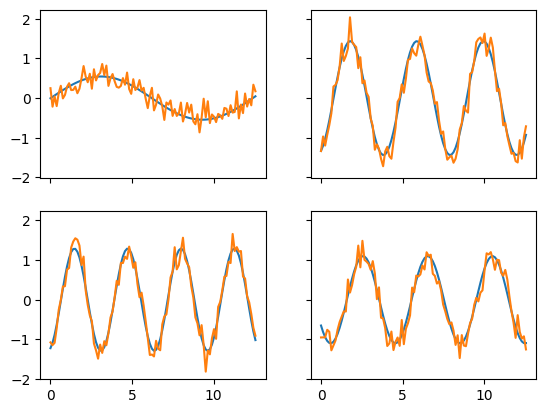

In [4]:
# plot clean vs noisy examples
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
ax = axes[0,0]
ax.plot(t, clean_curve[0,:])
ax.plot(t, noisy_curve[0,:])

ax = axes[1,0]
ax.plot(t, clean_curve[1,:])
ax.plot(t, noisy_curve[1,:])

ax = axes[0,1]
ax.plot(t, clean_curve[2,:])
ax.plot(t, noisy_curve[2,:])

ax = axes[1,1]
ax.plot(t, clean_curve[3,:])
ax.plot(t, noisy_curve[3,:])

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [14]:
# dataset split
X_train = noisy_curve[:9000,:]
X_val = noisy_curve[9000:,:]
Y_train = clean_curve[:9000,:]
Y_val = clean_curve[9000:,:]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [19]:
N = 100

autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [20]:
history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3935 - val_loss: 0.1660
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0808 - val_loss: 0.0405
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0296 - val_loss: 0.0188
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0167 - val_loss: 0.0141
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0132 - val_loss: 0.0116
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0108 - val_loss: 0.0100
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092 - val_loss: 0.0085
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - val_loss: 0.0080
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0075 - val_loss: 0.0070
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 - val_loss: 0.0065
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061 - val_lo

Plot the training and validation loss curves.

In [ ]:
# plot loss curves
plt.rcParams['font.size'] = 14
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.plot(epochs_range, train_loss, label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [ ]:
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) # Returns shape (4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

In [ ]:
# Plot clean / noisy / reconstructed for each example